# Задание 1 (синтаксис)

### Для каждого покупателя получите таблицу со столбцами:
```
 • preferred_payment - самый частый метод оплаты (при ничьей зафиксируйте правило, например lexicographically первый);
 • total_spent - сумма всех трат;
 • addons_spent - сумма на дополнительные услуги и аксессуары;
 • orders_count - число заказов.
 ```
Отсортируйте по total_spent по убыванию и выведите топ-10.

Пример вывода (формат; числа зависят от датасета):

```
   customer_id  preferred_payment  total_spent  addons_spent  orders_count
 0         C042     Credit Card              15420.50        890.00             7
 1         C018     PayPal                     14810.00        450.00             5
 2         C103     Debit Card               13990.25       1200.00             6
```

Пограничные случаи:

* Покупатель с одним заказом - orders_count = 1, preferred_payment = единственный метод.
* Два метода оплаты с одинаковой частотой - выберите один по зафиксированному правилу (укажите его в комментарии к коду).
* Покупатель без доп. услуг/аксессуаров - addons_spent = 0.
* Пропуски в сумме или методе оплаты - обработайте (отфильтруйте или заполните) и кратко опишите решение в комментарии.

In [5]:
import pandas as pd

df_source = pd.read_csv("./Electronic_sales_Sep2023-Sep2024.csv")

df_source_completed = df_source[df_source['Order Status'] != 'Cancelled']
df_source_completed['total_spent'] = df_source_completed['Total Price'] + df_source_completed['Add-on Total'] # Выбрал только те заказы, которые были выполнены
df_source_completed['customer_id'] = df_source_completed['Customer ID']

df_output = df_source_completed.groupby('customer_id').agg(
    preferred_payment=('Payment Method', lambda x: x.mode().iloc[0]), #mode возвращает список мод, если значения встречаются одинаково, вернет оба. iloc[0] возращает всегда первое значение
    total_spent=('total_spent', 'sum'),
    addons_spent=('Add-on Total', 'sum'), #числовой тип данных, если данных нет вернет 0
    orders_count=('customer_id', 'count')
).reset_index().sort_values(by='total_spent', ascending=True)



print(df_output.head(10))

      customer_id preferred_payment  total_spent  addons_spent  orders_count
52           1094        Debit Card        20.75           0.0             1
3453         7545              Cash        20.75           0.0             1
786          2453       Credit Card        20.75           0.0             1
2177         5079       Credit Card        20.75           0.0             1
3838         8248              Cash        20.75           0.0             1
2347         5419        Debit Card        20.75           0.0             1
3484         7595       Credit Card        20.75           0.0             1
344          1628       Credit Card        20.75           0.0             1
4668         9822              Cash        20.75           0.0             1
1527         3909       Credit Card        20.75           0.0             1


# Задание 2 (повышенная сложность)

### Постройте пайплайн на Pandas (без циклов по строкам):
 
 1. Очистка: типы дат, пропуски, аномалии (отрицательные суммы / нулевые цены) - кратко опишите, что отфильтровали.
 2. Метрики:
    * доход по методу доставки;
    * доход по типу продукта;
    * доход по доп. услугам: по месяцам и по кварталам;
    * cohort-анализ: когорта = месяц первого заказа покупателя; для каждой когорты - выручка и число покупателей в следующие 0, 1, 2, 3 месяца.
 3. Визуализация (минимум 3 графика): bar (доставка / тип продукта), line (доп. услуги по месяцам), heatmap когортной матрицы выручки.
 4. Выводы: несколько предложений по графикам. (?необязательно)
 
 Дополнительно: оформите шаги 1–2 как функции clean(df) → df и build_metrics(df) → dict[str, DataFrame].

Пример вывода метрик (фрагменты):
```
>>> metrics['revenue_by_shipping']
 shipping_method   revenue
 Express           125400.50
 Standard           98320.00
 Pickup             45110.75
 
 >>> metrics['addons_by_month'].head()
 month      addons_revenue
 2023-01           4200.00
 2023-02           3890.50
 2023-03           5100.00
 
 >>> metrics['cohort_revenue']  # строки — когорта, столбцы — месяц жизни 0..3
 cohort     0         1         2         3
 2023-01  15200.0   8100.0   4300.0   2100.0
 2023-02  14100.0   7600.0   3900.0      NaN
 ...
 ```

Графики: три отдельных figure/axes с подписями осей и заголовками. Числа в примере иллюстративные.

Пограничные случаи:

* Заказы с отрицательной или нулевой ценой - не должны попадать в доход после clean.
* Покупатель с одним заказом - в когортной матрице заполнен только месяц 0.
* Месяц без доп. услуг - в addons_by_month строка с 0 или отсутствие месяца (выберите и зафиксируйте поведение).
* Пустой датасет после очистки → функции не падают, возвращают пустые таблицы.




-------------------- total_revenue_by_month --------------------
         total_revenue
month                 
2023-09      283635.75
2023-10     1555325.86
2023-11     1390116.50
2023-12     1310022.87
2024-01     4516277.81
2024-02     3897250.16
2024-03     4226126.65
2024-04     4300323.69
2024-05     4462915.20
2024-06     4465994.71


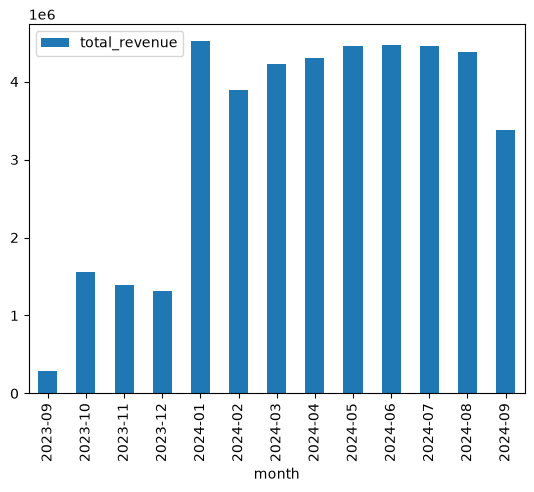

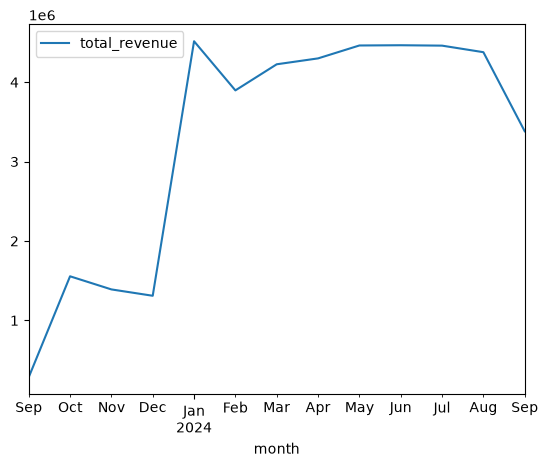


-------------------- total_revenue_by_quarter --------------------
         total_revenue
quarter               
2023Q3       283635.75
2023Q4      4255465.23
2024Q1     12639654.62
2024Q2     13229233.60
2024Q3     12221626.37


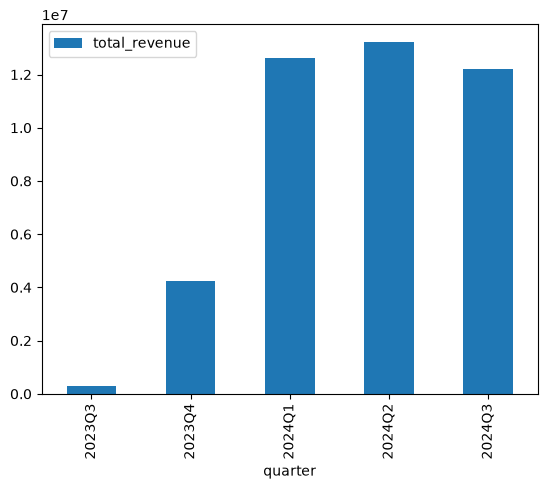

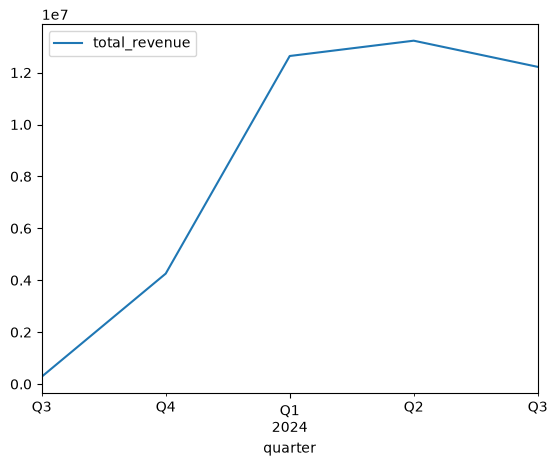


-------------------- addons_revenue_by_month --------------------
         addons_revenue
month                  
2023-09         5337.61
2023-10        26153.21
2023-11        24453.33
2023-12        22750.23
2024-01        93254.95
2024-02        80253.72
2024-03        84713.93
2024-04        82294.06
2024-05        89374.18
2024-06        84648.60


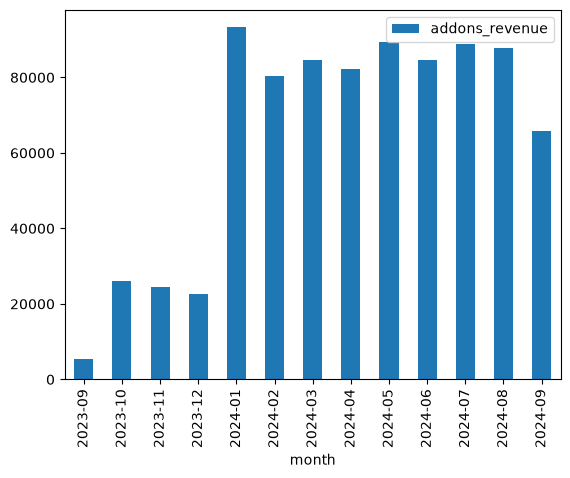

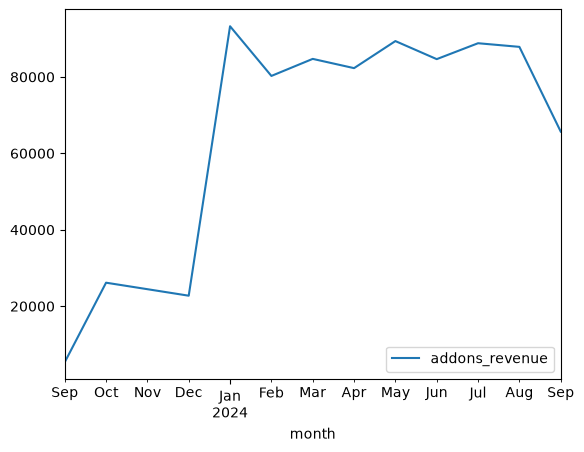


-------------------- addons_revenue_by_quarter --------------------
         addons_revenue
quarter                
2023Q3          5337.61
2023Q4         73356.77
2024Q1        258222.60
2024Q2        256316.84
2024Q3        242361.42


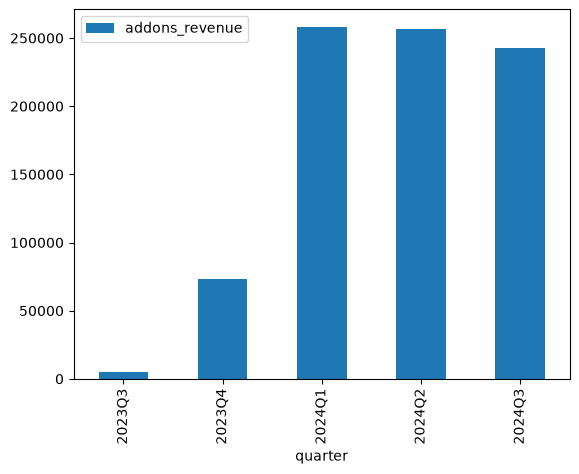

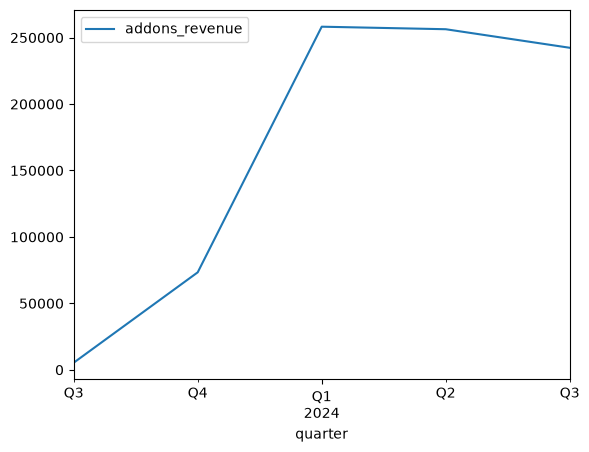


-------------------- revenue_on_shipping_type --------------------
               total_revenue
Shipping Type               
Expedited         8610437.09
Express           5725863.77
Overnight         5982983.40
Same Day          8469574.60
Standard         14676351.95


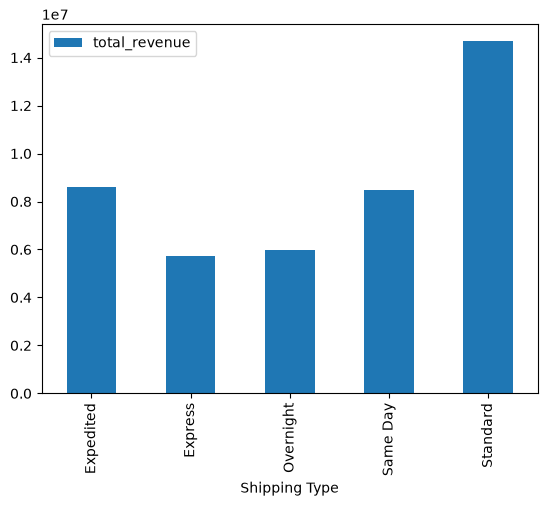

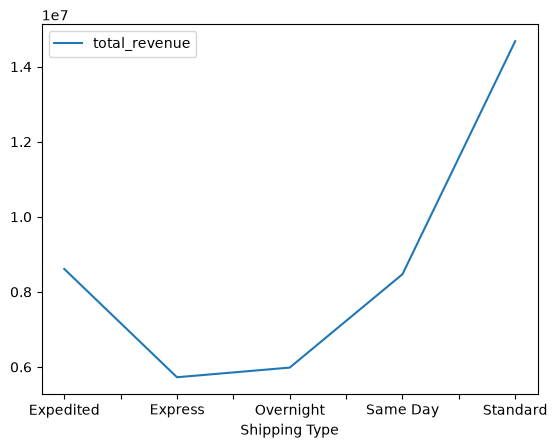


-------------------- cohort_revenue --------------------
cohort_index           0          1          2          3
cohort                                                   
2023-09        288973.36   33966.24   27171.95   33728.93
2023-10       1547512.83   57546.84  105708.66  105318.56
2023-11       1329851.04   51831.74  120410.29   49399.43
2023-12       1141503.77   70631.39   51051.53   66268.75
2024-01       4300575.58  224810.52  363311.35  367531.56
2024-02       3551138.51  237765.99  258807.13  276145.83
2024-03       3492721.17  309227.62  249389.13  247959.27
2024-04       3176736.50  255450.10  270533.88  246163.28
2024-05       3129140.50  184409.51  242471.91  186356.86
2024-06       2835280.78  270002.95  198649.97  216222.09


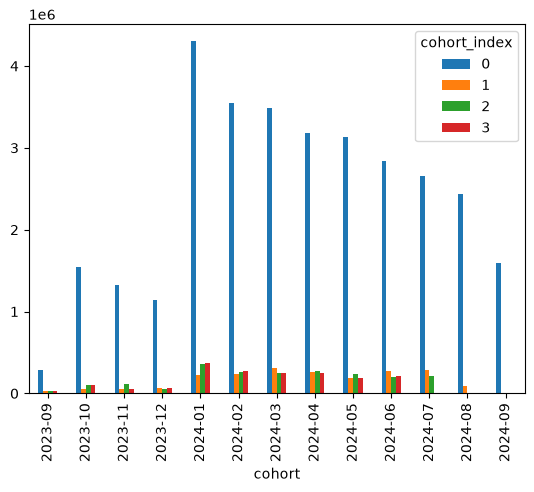

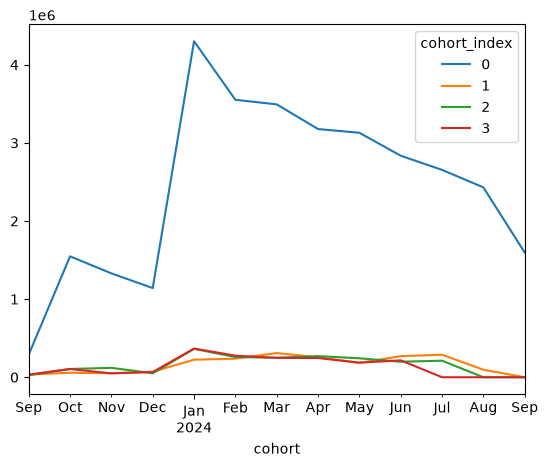


-------------------- cohort_count_customers --------------------
cohort_index     0   1   2   3
cohort                        
2023-09        124  11  12  13
2023-10        602  28  36  36
2023-11        497  22  39  24
2023-12        454  27  16  26
2024-01       1290  74  90  91
2024-02       1072  67  72  77
2024-03       1062  83  72  75
2024-04        946  78  77  65
2024-05        939  56  68  54
2024-06        837  71  54  55


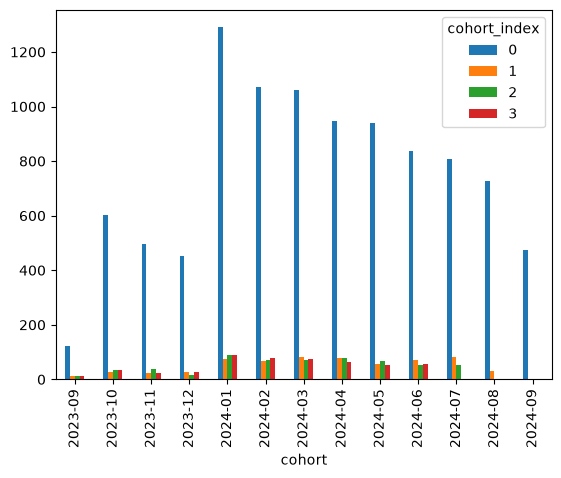

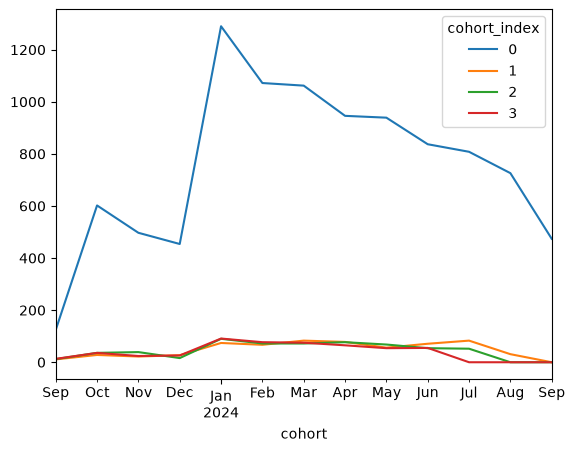

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

def build_metrics(df: pd.DataFrame) -> dict[str: pd.DataFrame]:
    metrics = {'total_revenue_by_month': None,
               'total_revenue_by_quarter': None,
               'addons_revenue_by_month': None,
               'addons_revenue_by_quarter': None,
               'revenue_on_shipping_type': None,
               'cohort_revenue': None,
               'cohort_count_customers': None}

    df = df.copy()

    #by month
    df['month'] = df['Purchase Date'].dt.to_period('M')
    metrics['total_revenue_by_month'] = df.groupby('month').agg(
        #month=('Purchase Date', lambda x: x.dt.strftime('%Y-%m')),
        total_revenue=('Total Price', 'sum')
    )

    metrics['addons_revenue_by_month'] = df.groupby('month').agg(
        #month=('Purchase Date', lambda x: x.dt.strftime('%Y-%m')),
        addons_revenue=('Add-on Total', 'sum')
    )

    #by_quarter
    df['quarter'] = df['Purchase Date'].dt.to_period('Q')
    metrics['total_revenue_by_quarter'] = df.groupby('quarter').agg(
        total_revenue=('Total Price', 'sum')
    )

    metrics['addons_revenue_by_quarter'] = df.groupby('quarter').agg(
        #month=('Purchase Date', lambda x: x.dt.strftime('%Y-%m')),
        addons_revenue=('Add-on Total', 'sum')
    )

    metrics['revenue_on_shipping_type'] = df.groupby('Shipping Type').agg(
        total_revenue=('total_spent', 'sum')
    )

    df['cohort'] = df.groupby('Customer ID')['month'].transform('min')
    df['cohort_index'] = (df['month'].astype(int) - df['cohort'].astype(int))

    metrics['cohort_revenue'] = df.pivot_table(
        index='cohort',
        columns='cohort_index',
        values='total_spent',
        aggfunc='sum',
        fill_value=0 #NaN меняем на нули
    ).reindex(columns=[0, 1, 2, 3])

    metrics['cohort_count_customers'] = df.pivot_table(
        index='cohort',
        columns='cohort_index',
        values='Customer ID',
        aggfunc='count',
        fill_value=0
    ).reindex(columns=[0, 1, 2, 3])

    return metrics

    

df_source = pd.read_csv("./Electronic_sales_Sep2023-Sep2024.csv")

df_source_completed = df_source[df_source['Order Status'] != 'Cancelled'] #убрали отмененные
df_source_completed['total_spent'] = df_source_completed['Total Price'] + df_source_completed['Add-on Total']
df_source_completed['Purchase Date'] = pd.to_datetime(df_source_completed['Purchase Date']) #преобразование к типу datetime

for name_metric, metric in build_metrics(df_source_completed).items():
    print(f"\n-------------------- {name_metric} --------------------")
    print(metric.head(10))
    metric.plot.bar()
    plt.show()
    metric.plot.line()
    plt.show()

